Exhaustive search for RU selection
----------------------------
An example of exhaustive search/flickering to perform RU selection.

In [1]:
%cd "/home/user/6GTandem-simulator"
import yaml
import numpy as np
import pandas as pd
import concurrent.futures
import matplotlib.pyplot as plt

from plotter import plotter
from wireless_channel.waveforms import Waveform
from sub_THz_stripe.radiostripe.radiostripe import RadioStripe
from sub_THz_stripe.radio_unit.radio_unit import RadioUnit
from wireless_channel.subTHz_channel import Channel
from sub_THz_stripe.central_unit.central_unit import CentralUnit
from sub_THz_stripe.utils import getdbm, calculate_sndr

/home/user/6GTandem-simulator


In [2]:
# Read out the config file.
config_file = "examples/flickering/config.yml"
with open(config_file, "r", encoding="utf8") as file:
    config = yaml.safe_load(file)

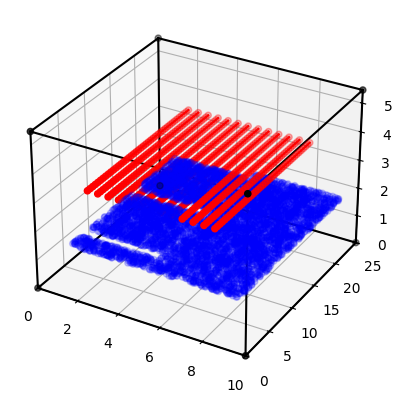

In [3]:
# Plot the room with the strip in it.
plotter.plot_room(config)

In [4]:
# Construct the waveform class based on the loaded configuration.
waveform_config = config["waveform_config"]
freq_band_config = config["sub_thz"]
wf = Waveform.from_config(waveform_config, freq_band_config)

In [5]:
# Generate an CP-OFDM waveform in the time domain.
bits = wf.generate_bits()
qam = wf.qam_modulate()
ofdm_time = wf.ofdm_modulate()  # shape: nr_ofdm_symb x (fftsize + cp length)

# Thomas F. manier
pavg = np.mean(np.abs(ofdm_time) ** 2)
alpha = np.sqrt(1 / pavg)
ofdm_time = ofdm_time * alpha
pavg = 10 * np.log10(np.mean(np.abs(ofdm_time) ** 2) / 1e-3)
print(pavg)

30.0


In [6]:
# The UE has the same hardware as a central unit.
ue = CentralUnit()  # todo are these configs loadable?
ofdm_time_after_ue = ue.run(ofdm_time)  # shape: nr_ofdm_symbols x (fft_size + cp length)

# A single radio unit is used to represent the transmit stage of the ue. The UE position does not influence the
# transmission so we can set it arbitrarily.
ue_ru = RadioUnit(x=0, y=0, z=0, wf=wf)

In [7]:
# Build all the RadioStripe objects based on the configuration.
stripes: list[RadioStripe] = []
component_config = config["component_config"]
stripe_cfg = config["radio_stripes"][0]
for stripe_cfg in config["radio_stripes"]:
    stripes.append(RadioStripe.from_config_locations(stripe_cfg, component_config, wf))

In [9]:
def receive_worker(stripe: RadioStripe, data, phase_shifts, ue_idx, stripe_idx, ru_idx):
    stripe.active_unit = ru_idx
    y, imdata = stripe.receive(data, phase_shifts, False)

    out = [ue_idx, stripe_idx, ru_idx, y]
    return out

def ue_worker(ue_pos: dict, wf: Waveform, stripes: list[RadioStripe]):
    # TODO: Take the number of antennas from the configuration.
    ue_data = []
    for ue_beam in range(1):
        for ru_beam in range(1):
            # Transmit the data towards the stripe. We only perform this task once. Every UE in the room will transmit the same
            # signal towards the stripe. Only its position and hence the channel will change.
            ue_shift = ue_ru.phase_shifter.get_phases(ue_beam)
            iq_data_tx, imdata = ue_ru.transmit(ofdm_time_after_ue, ue_shift)

            # Construct the wireless channel for this UE.
            channel = Channel.from_sionna(ue_pos, "ue_locations_5681.nc")

            # Transmit the data over the channel and get the data at all the radio units.
            iq_data_rx = channel.transmit_ul(iq_data_tx, wf)

            # Now receive this data on all the stripes.
            for stripe_idx, (stripe, data) in enumerate(zip(stripes, iq_data_rx)):
                ru_shift = stripe.radio_units[0].phase_shifter.get_phases(ru_beam)
                for ru_idx in range(len(stripe.radio_units)): 
                    # Receive the data over the stripe coming from ru_idx.
                    stripe.active_unit = ru_idx
                    y, imdata = stripe.receive(data, ru_shift, False)

                    # Calculate the sndr and average power received on the antennas of the RU.
                    pavg_ru = getdbm(iq_data_rx[stripe_idx][ru_idx])
                    sndr_ru, _ = calculate_sndr(ofdm_time, imdata[4], wf)
                    # Calculate the sndr and average power received at the CU.
                    pavg_cu = getdbm(y)
                    sndr_cu, _ = calculate_sndr(ofdm_time, y, wf)
                    # Save the data.
                    ue_data.append([channel.ue_idx, stripe_idx, ru_idx, ue_beam, ru_beam, pavg_ru, pavg_cu, sndr_ru, sndr_cu])
            
            # Save the data to disk.
            df = pd.DataFrame(ue_data, columns=["ue_id", "stripe_id", "ru_id", "ue_beam_id", "ru_beam_id", "pavg_ru", "pavg_cu", "sndr_ru", "sndr_cu"])
            df.to_pickle(f"simulations/flickering_data_{channel.ue_idx}.pkl")
            
# Loop over all the UE positions and perform an exhaustive search.
workers = []
ue_worker(config["ue_positions"][0], wf, stripes)
with concurrent.futures.ProcessPoolExecutor(max_workers=32) as executor:
    for ue_pos in config["ue_positions"][:6]:
        worker = executor.submit(ue_worker, ue_pos, wf, stripes)
        workers.append(worker)
    
    concurrent.futures.wait(workers)

KeyboardInterrupt: 